# Exercise 3.B More Plotting Practice

In [3]:
import numpy as np               # Importing for array operations and data manipulation
import matplotlib.pyplot as plt  # Importing for creating visualizations and plots

# A command that displays plots directly in the notebook
%matplotlib inline  

## Advanced Plotting Techniques

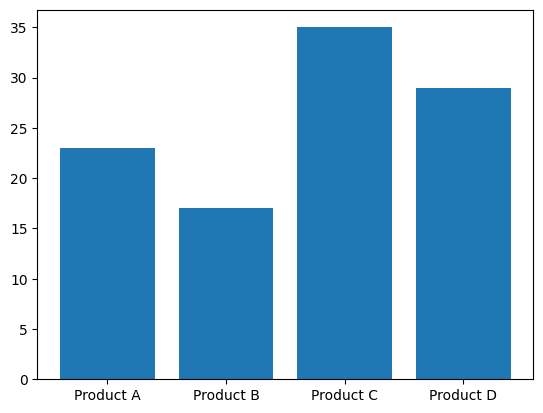

In [4]:
# Creating a simple bar chart showing sales of different products

products = ['Product A', 'Product B', 'Product C', 'Product D'] 
sales = [23, 17, 35, 29] 

plt.bar(products, sales)
plt.show()

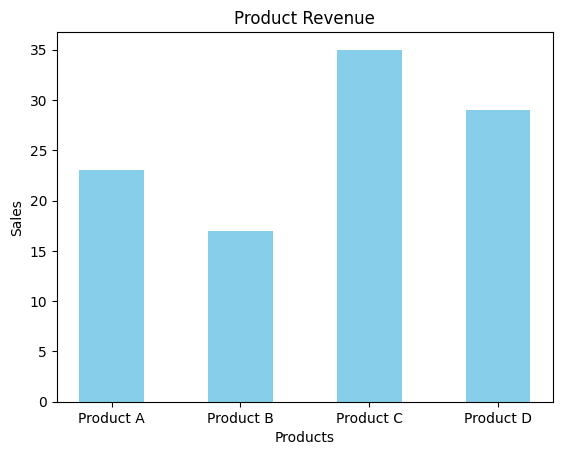

In [7]:
# Customizing previous bar chart by adding labels and bar attributes
# fmt is only a parameter of plt.plot, so I can only use it with line charts

plt.bar(
    products, sales,  # don't forget commas!
    color="skyblue",  # changes bar color
    width=0.5         # bar width (0 to 1; default is 0.8)
)

plt.title("Product Revenue")
plt.xlabel("Products")
plt.ylabel("Sales")
plt.show()

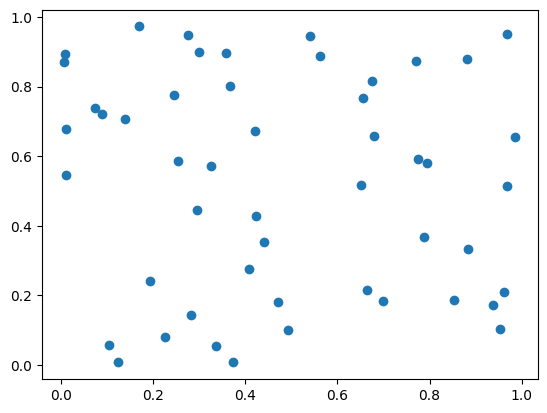

In [9]:
# Creating a Scatter Plot to visualize the relationships between two variables
# A scatter plot places individual dots on a grid to show the relationship
# between two numeric variables

# np.random.rand(50) generates 50 random numbers between 0 and 1
# each number becomes a coordinate point on the chart
x = np.random.rand(50)  # x-axis values (horizontal position of each dot)
y = np.random.rand(50)  # y-axis values (vertical position of each dot)

# each pair (x[0], y[0]), (x[1], y[1])... becomes one dot on the chart
# I should have 50 dots
plt.scatter(x, y)
plt.show()
# each dot represents one obervation

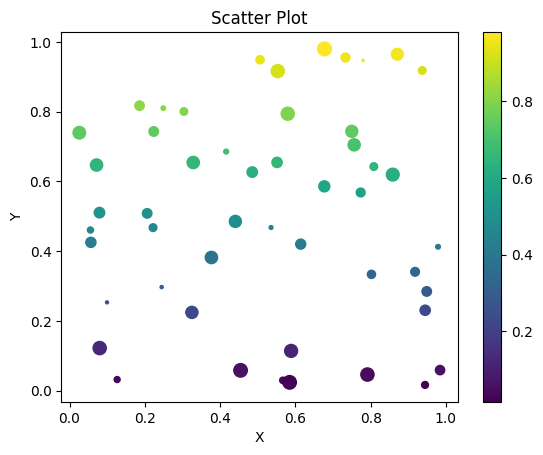

In [12]:
# Adding a third variable 's' (can be anything) to control the size of each dot 
# and using colormaps

x = np.random.rand(50)  
y = np.random.rand(50)  

s = np.random.rand(50) * 100  
# Since random.rand() generates random floats 0 to 1, the dots would be too small,
# so *100 makes them bigger

# c=y uses the y-axis values to determine each dot's color. it gives the data
# cmap='viridis' is the color scheme (yellow = high values, purple = low
# without c=, cmap has nothing to map colors to
# colorbar() adds a color scale legend on the side so you can read the colors
plt.scatter(x, y, s=s, c=y, cmap='viridis')
plt.colorbar()

plt.title("Scatter Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

### **Scatter Plot Breakdown**

A scatter plot is used to visualize the relationship between two variables, where each dot represents one observation.

- In this case, `x` and `y` determine where each dot is positioned on the chart. `s` is a variable that stores both the value and the size of each dot.
  - Since `np.random.rand(50)` generates 50 random floats between 0 and 1, the dots would be too small to see clearly, so multiplying by 100 scales them up to a visible size between 0 and 100, where the bigger the number the bigger the dot appears.
- `c=y` maps the y-axis values to colors, meaning each dot's color is determined by how high or low its y value is.
- `cmap='viridis'` sets the color scheme where purple/dark blue represents low y values, green represents mid values, and yellow represents high values.
- The colorbar on the right is the legend that shows this color-to-value mapping — without `c=y`, cmap would have nothing to map colors to and would have no effect.

**Colormaps always map the smallest values to one end of the color scale and the largest values to the other end.**

## Subplots

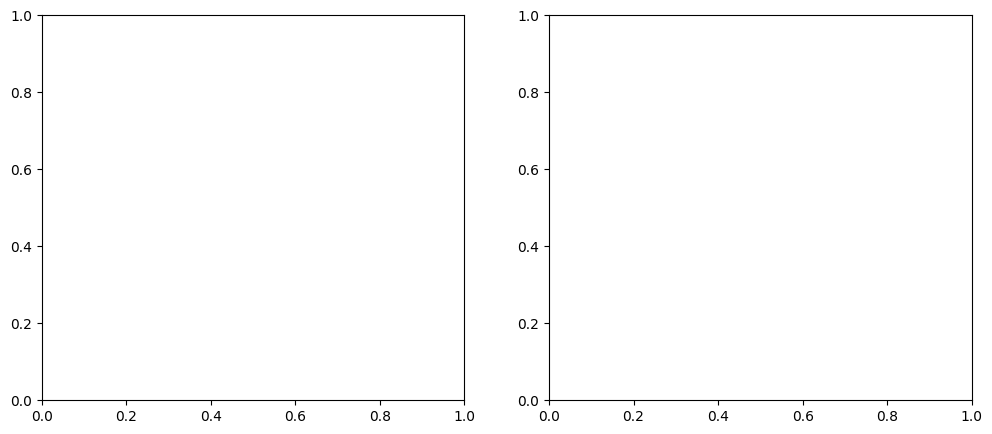

In [20]:
# Creating the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.show()
# plt.subplots() creates and returns the figure and axes objects at the same time
# 1 = number of rows of subplots, 2 = number of columns of subplots (side by side)
# figsize=(12, 5) sets the size of the entire figure in inches — width=12, height=5
# fig is the Figure object. The entire outer canvas that holds both charts together
# figsize controls the size of the entire outer canvas
# making it bigger stretches everything inside including both charts to fill the space
# (ax1, ax2) are Axes objects, each one represents one individual chart/subplot
# each Axes object includes everything inside it: plot area, axes, ticks, labels, and data
# fig is NOT one of the individual charts; it is the big container holding ax1 and ax2
# ax1 = left subplot, ax2 = right subplot

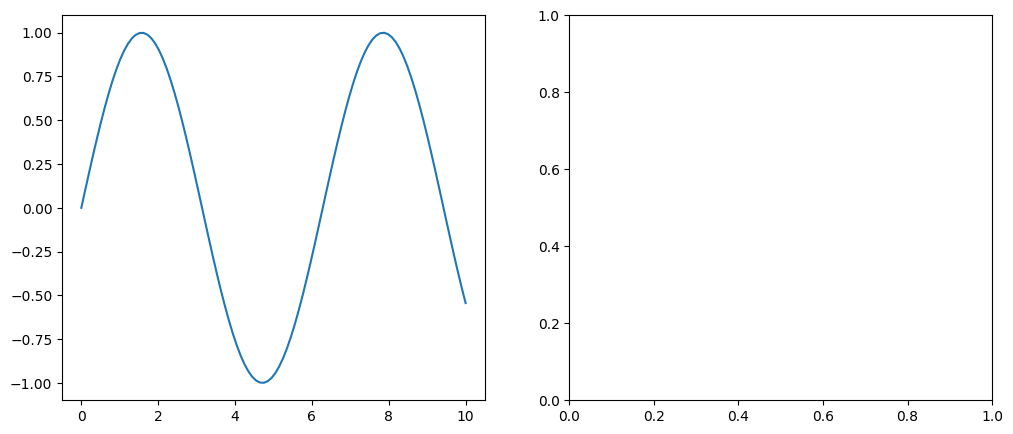

In [22]:
# Adding the sine wave to the first subplot

# np.linspace(0, 10, 100) generates 100 evenly spaced x values between 0 and 10
# 0 = start, 10 = end, 100 = number of values to generate
# the gap between each value is roughly 0.101 (10/99)
# the more values generated, the smoother the wave appears on the chart

x = np.linspace(0, 10, 100)

# np.sin(x) calculates the sine of each x value
# y = np.sin(x) calculates a height value for each of the 100 x values
# x is 100 positions along the x-axis
# at each position, np.sin(x) gives a height between -1 and 1
# some positions get a high height, some low, some zero
# when matplotlib connects all 100 (x position, y height) points with a line
# the result looks like a wave because the heights naturally go up and down
y = np.sin(x)

# recreating the figure with two empty subplots for this cell
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ax1.plot(x, y) plots the sine wave on the LEFT subplot only
# ax1 is the definer — using ax1 targets the left chart, ax2 would target the right

ax1.plot(x, y)
plt.show()

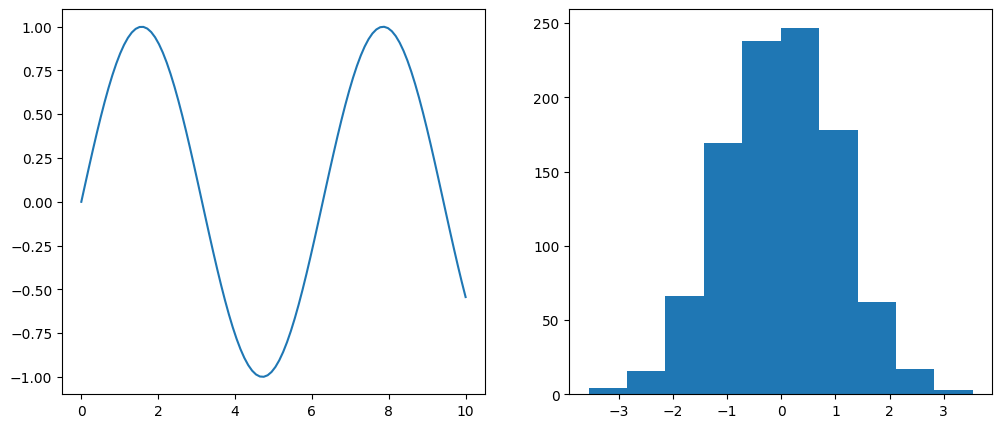

In [23]:
# Adding the histogram to the second subplot

# data is a variable that stores 1000 randomly generated numbers
# randn is used instead of randint because randn generates numbers following a normal distribution
# meaning most values cluster around 0 with fewer values further away, creating a bell curve shape
# randint generates completely random integers with equal probability
# which would produce a flat histogram instead of a bell curve
data = np.random.randn(1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x = np.linspace(0, 10, 100)
y = np.sin(x)

ax1.plot(x, y)

# ax2.hist(data) takes the 1000 numbers in data and groups them into bins
# matplotlib automatically divides the range of data into equal-width bins
# range = distance from the smallest value to the largest value
# e.g. if data goes from -3 to 3, the range is 6 and matplotlib splits it into equal chunks
# each bin counts how many of the 1000 values fall within that interval
# the height of each bar shows how many values landed in that bin
# you can control the number of bins yourself with bins=20 for example
# ax2 targets the right subplot specifically
ax2.hist(data)
plt.show()

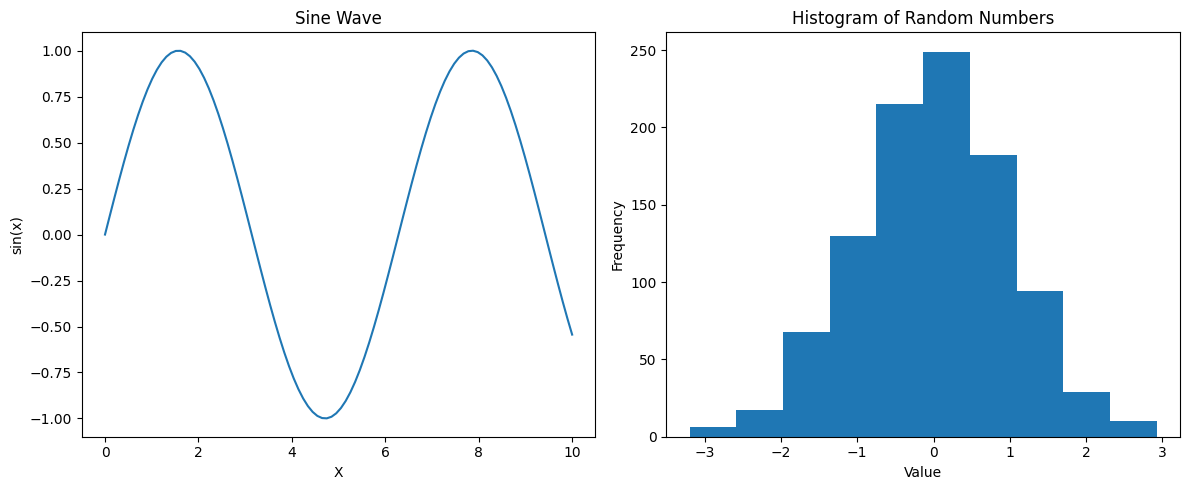

In [24]:
# Adding titles and labels to each subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x = np.linspace(0, 10, 100)
y = np.sin(x)
data = np.random.randn(1000)
ax1.plot(x, y)
ax1.set_title("Sine Wave")
ax1.set_xlabel("X")
ax1.set_ylabel("sin(x)")
ax2.hist(data)
ax2.set_title("Histogram of Random Numbers")
ax2.set_xlabel("Value")
ax2.set_ylabel("Frequency")
plt.tight_layout()
plt.show()